<a href="https://colab.research.google.com/github/deepan98raj-dotcom/Assessment/blob/main/K_means_cluster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. Load the data

df = pd.read_csv('/content/cluster_data.csv')
print(df.head())
print(df.shape)

   Feature 1  Feature 2
0   2.698582  -0.672960
1  -0.128113   4.355952
2   2.509049   5.773146
3  -1.518276   3.444886
4  -0.072283   2.883769
(500, 2)


In [ ]:
#Summary

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature 1  500 non-null    float64
 1   Feature 2  500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


Loaded 500 rows. Clustering on: ['Feature 1', 'Feature 2', 'cluster']
Chosen k = 2 (silhouette score = 0.745)
Saved plot to kmeans_clusters.png
Saved labeled data to /root/.local/share/jupyter/runtime/kernel-cfbfec42-46b1-40b9-8402-b57cafcb7674.json

Cluster sizes:
cluster
0    397
1    103


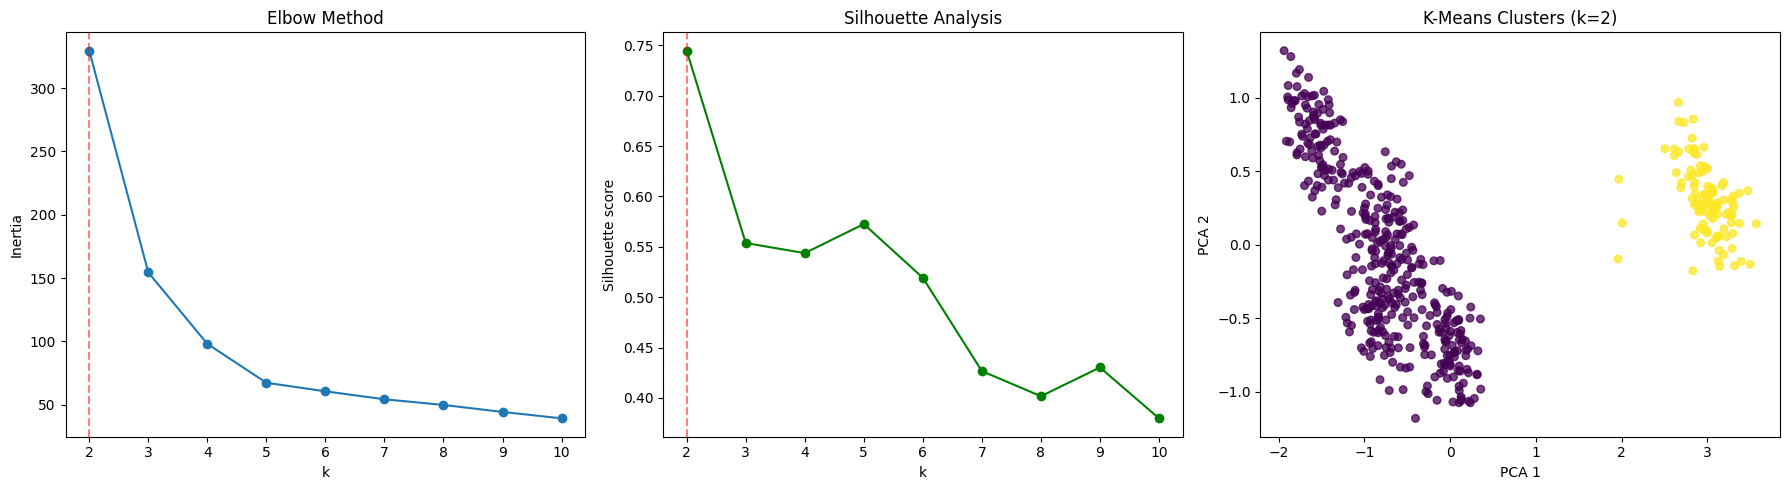

In [ ]:

feature_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Loaded {df.shape[0]} rows. Clustering on: {feature_cols}")

X = df[feature_cols].values
DATA_PATH = sys.argv[1] if len(sys.argv) > 1 else "cluster_data.csv"
OUTPUT_CSV = sys.argv[2] if len(sys.argv) > 2 else "clustered_data.csv"
OUTPUT_PLOT = sys.argv[3] if len(sys.argv) > 3 else "kmeans_clusters.png"
K_RANGE = range(2, 11)     # candidate number of clusters to try
RANDOM_STATE = 42

# 2. Scale features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias, sil_scores = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]
print(f"Chosen k = {best_k} (silhouette score = {max(sil_scores):.3f})")

# 3. Fit the final model at the chosen k

kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE)
df["cluster"] = kmeans.fit_predict(X_scaled)

# 4. Visualize: elbow curve, silhouette curve, final clusters

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(K_RANGE), inertias, "o-")
axes[0].axvline(best_k, color="red", linestyle="--", alpha=0.5)
axes[0].set(xlabel="k", ylabel="Inertia", title="Elbow Method")

axes[1].plot(list(K_RANGE), sil_scores, "o-", color="green")
axes[1].axvline(best_k, color="red", linestyle="--", alpha=0.5)
axes[1].set(xlabel="k", ylabel="Silhouette score", title="Silhouette Analysis")

if len(feature_cols) == 2:
    # Data is already 2D -> plot the real features directly
    axes[2].scatter(df[feature_cols[0]], df[feature_cols[1]],
                     c=df["cluster"], cmap="viridis", s=30, alpha=0.75)
    centers = scaler.inverse_transform(kmeans.cluster_centers_)
    axes[2].scatter(centers[:, 0], centers[:, 1], c="red", marker="X",
                     s=200, edgecolor="black", label="Centroids")
    axes[2].set(xlabel=feature_cols[0], ylabel=feature_cols[1])
    axes[2].legend()
else:
    # More than 2 features -> project to 2D with PCA just to visualize
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_scaled)
    axes[2].scatter(coords[:, 0], coords[:, 1], c=df["cluster"], cmap="viridis", s=30, alpha=0.75)
    axes[2].set(xlabel="PCA 1", ylabel="PCA 2")
axes[2].set_title(f"K-Means Clusters (k={best_k})")

plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150)
print(f"Saved plot to {OUTPUT_PLOT}")

# 5. Save labeled data

df.to_csv(OUTPUT_CSV, index=False)
print(f"Saved labeled data to {OUTPUT_CSV}")
print("\nCluster sizes:")
print(df["cluster"].value_counts().sort_index().to_string())